# 06b — CLEAR VAE Latent-Space Analysis

## VAE extension — diagnostica dello spazio latente

Questo notebook analizza il **vero VAE** addestrato nel `06a_CLEAR_Peptide_VAE_Training.ipynb`.

La Pipeline 2 consolidata resta separata e invariata.

```text
Pipeline 2 consolidata:
04c → 04d → 04e → 05c → 05d → 05e

VAE extension:
06a VAE training
→ 06b latent-space analysis   ← questo notebook
→ 06c latent counterfactual optimization
→ 06d VAE-CLEAR vs Direct CLEAR
```

## Obiettivo

Il 06a ha mostrato:

- seed F0010 ricostruito correttamente;
- KL non collassata;
- varianza latente non nulla;
- accuratezza per-residuo test inferiore al criterio conservativo del 90%.

Il 06b verifica quindi se lo spazio latente è **scientificamente utile**, anche senza ricostruzione perfetta.

Le domande principali sono:

1. sequenze più simili sono anche più vicine nel latent space?
2. seed, singole e doppie mutazioni occupano regioni coerenti?
3. il target 04c mostra una struttura nello spazio latente?
4. i controfattuali CLEAR già noti occupano regioni interpretabili?
5. esiste sufficiente smoothness locale per tentare nel 06c una ricerca counterfactual nello spazio `z`?

Questo notebook **non genera ancora nuovi controfattuali**.


## 1. Dipendenze

In [1]:
from pathlib import Path
import json
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)

RANDOM_SEED = 42
SEED_SEQUENCE = "IGERCQYRDLK"
OUTPUT_DIR = Path("outputs")

RESULT_DIR = OUTPUT_DIR / "clear_peptide_vae_06b"
REPORTS_DIR = RESULT_DIR / "reports"

for directory in [RESULT_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Output:", RESULT_DIR.resolve())

Output: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b


## 2. Individuazione degli output 06a e del dataset 04c

In [2]:
VAE06A_DIR = OUTPUT_DIR / "clear_peptide_vae_06a"

LATENT_CANDIDATES = [
    VAE06A_DIR / "vae_latent_embeddings.csv",
]

CONFIG_CANDIDATES = [
    VAE06A_DIR / "models" / "clear_peptide_vae_config.json",
]

DATASET_CANDIDATES = [
    OUTPUT_DIR
    / "clear_local_peptide_dataset_04c"
    / "clear_local_peptide_variant_dataset_labeled.csv",
    OUTPUT_DIR
    / "clear_local_peptide_dataset_04c"
    / "clear_local_peptide_variant_dataset.csv",
]


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


LATENT_PATH = first_existing(LATENT_CANDIDATES)
CONFIG_PATH = first_existing(CONFIG_CANDIDATES)
DATASET_PATH = first_existing(DATASET_CANDIDATES)

if LATENT_PATH is None:
    matches = sorted(
        OUTPUT_DIR.rglob("vae_latent_embeddings.csv")
    )
    if not matches:
        raise FileNotFoundError(
            "vae_latent_embeddings.csv del 06a non trovato."
        )
    LATENT_PATH = matches[0]

if DATASET_PATH is None:
    matches = sorted(
        OUTPUT_DIR.rglob("*clear*variant*dataset*labeled*.csv")
    )
    if not matches:
        matches = sorted(
            OUTPUT_DIR.rglob("*clear*variant*dataset*.csv")
        )
    if not matches:
        raise FileNotFoundError(
            "Dataset 04c non trovato."
        )
    DATASET_PATH = matches[0]

print("Latent embeddings:", LATENT_PATH.resolve())
print("Dataset 04c:", DATASET_PATH.resolve())
print(
    "Config 06a:",
    CONFIG_PATH.resolve()
    if CONFIG_PATH is not None
    else "non trovata"
)

Latent embeddings: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/vae_latent_embeddings.csv
Dataset 04c: /Users/robertobruzzese/Desktop/venv/outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset_labeled.csv
Config 06a: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06a/models/clear_peptide_vae_config.json


## 3. Caricamento e merge

In [3]:
latent_df = pd.read_csv(LATENT_PATH)
dataset = pd.read_csv(DATASET_PATH)

sequence_column = next(
    (
        column for column in [
            "sequence",
            "mutant_sequence",
            "variant_sequence",
            "peptide_sequence",
        ]
        if column in dataset.columns
    ),
    None,
)

if sequence_column is None:
    raise ValueError(
        "Colonna sequenza non riconosciuta nel dataset 04c."
    )

dataset[sequence_column] = (
    dataset[sequence_column]
    .astype(str)
    .str.strip()
    .str.upper()
)

latent_sequence_column = next(
    (
        column for column in [
            "sequence",
            sequence_column,
            "mutant_sequence",
            "variant_sequence",
            "peptide_sequence",
        ]
        if column in latent_df.columns
    ),
    None,
)

if latent_sequence_column is None:
    raise ValueError(
        "Colonna sequenza non riconosciuta negli embeddings 06a."
    )

latent_df[latent_sequence_column] = (
    latent_df[latent_sequence_column]
    .astype(str)
    .str.strip()
    .str.upper()
)

if (
    latent_sequence_column != sequence_column
):
    latent_df = latent_df.rename(
        columns={
            latent_sequence_column:
            sequence_column
        }
    )

merged = latent_df.merge(
    dataset,
    on=sequence_column,
    how="left",
    suffixes=("_latent", "_04c"),
)

z_columns = [
    column for column in merged.columns
    if column.startswith("z")
    and column[1:].isdigit()
]

if not z_columns:
    raise ValueError(
        "Coordinate latenti z1, z2, ... non trovate."
    )

z_columns = sorted(
    z_columns,
    key=lambda x: int(x[1:]),
)

print("Sequenze latent:", len(latent_df))
print("Sequenze dataset:", len(dataset))
print("Sequenze merge:", len(merged))
print("Latent dimensions:", z_columns)

display(
    merged[
        [sequence_column]
        + z_columns
    ].head()
)

Sequenze latent: 539
Sequenze dataset: 539
Sequenze merge: 539
Latent dimensions: ['z1', 'z2', 'z3', 'z4']


,sequence,z1,z2,z3,z4
0,IGERCQYRDLK,0.237059,-0.637343,-0.416996,-0.194805
1,AGERCQYRDLK,0.050846,-0.381439,0.951113,-1.084407
2,FGERCQYRDLK,0.069325,-0.098650,0.106302,-1.588990
3,LGERCQYRDLK,0.172019,-0.472641,0.886911,-1.323767
4,MGERCQYRDLK,0.039245,-0.506157,1.127405,-0.487123


## 4. Identificazione del target 04c

Il target principale atteso dalla Pipeline 2 è `oracle_target_composite_preliminary`.

Se il nome non è presente, il notebook cerca automaticamente colonne numeriche plausibili contenenti `target`, `score`, `energy` o `ddg`.


In [4]:
TARGET_CANDIDATES = [
    "oracle_target_composite_preliminary",
    "oracle_target",
    "target",
    "composite_target",
    "composite_score",
]

target_column = next(
    (
        column
        for column in TARGET_CANDIDATES
        if column in merged.columns
    ),
    None,
)

if target_column is None:
    numeric_columns = merged.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    heuristic = [
        column
        for column in numeric_columns
        if any(
            token in column.lower()
            for token in [
                "target",
                "score",
                "energy",
                "ddg",
            ]
        )
        and column not in z_columns
    ]

    if heuristic:
        target_column = heuristic[0]

if target_column is None:
    raise ValueError(
        "Target 04c non individuato automaticamente. "
        "Impostare manualmente target_column."
    )

print("Target selezionato:", target_column)

target_summary = merged[
    target_column
].describe()

display(
    target_summary.to_frame(
        "value"
    )
)

Target selezionato: oracle_target_composite_preliminary


,value
count,539.000000
mean,0.608728
std,0.126187
min,0.200197
25%,0.536658
50%,0.629244
75%,0.700094
max,0.848590


## 5. Distanza di Hamming e distanza latente da F0010

In [5]:
def hamming_distance(seq_a, seq_b):
    return sum(
        aa != bb
        for aa, bb in zip(seq_a, seq_b)
    )


if "hamming_to_seed" not in merged.columns:
    merged["hamming_to_seed"] = (
        merged[sequence_column]
        .apply(
            lambda sequence:
            hamming_distance(
                sequence,
                SEED_SEQUENCE,
            )
        )
    )

seed_rows = merged[
    merged[sequence_column]
    == SEED_SEQUENCE
].copy()

if seed_rows.empty:
    raise ValueError(
        "Seed F0010 non trovato negli embeddings."
    )

seed_z = seed_rows[
    z_columns
].iloc[0].to_numpy(
    dtype=float
)

Z = merged[
    z_columns
].to_numpy(
    dtype=float
)

merged["latent_distance_to_seed"] = (
    np.linalg.norm(
        Z - seed_z[None, :],
        axis=1,
    )
)

distance_by_hamming = (
    merged.groupby(
        "hamming_to_seed"
    )["latent_distance_to_seed"]
    .agg(
        ["count", "mean", "std", "min", "max"]
    )
)

display(distance_by_hamming)

,count,mean,std,min,max
hamming_to_seed,,,,,
0,1,0.000000,NaN,0.000000,0.000000
1,38,1.361764,0.428955,0.394255,2.083758
2,500,1.842796,0.454007,0.266350,2.973882


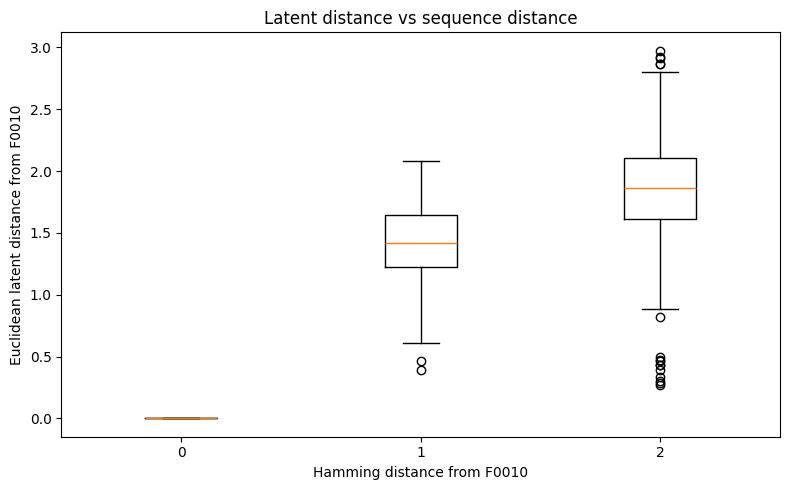

In [6]:
plt.figure(figsize=(8, 5))

groups = [
    merged.loc[
        merged["hamming_to_seed"] == value,
        "latent_distance_to_seed",
    ].to_numpy()
    for value in sorted(
        merged["hamming_to_seed"].unique()
    )
]

labels = [
    str(value)
    for value in sorted(
        merged["hamming_to_seed"].unique()
    )
]

plt.boxplot(
    groups,
    labels=labels,
)

plt.xlabel("Hamming distance from F0010")
plt.ylabel("Euclidean latent distance from F0010")
plt.title("Latent distance vs sequence distance")
plt.tight_layout()

plt.savefig(
    REPORTS_DIR
    / "latent_distance_by_hamming.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Correlazione globale tra distanza di sequenza e distanza latente

Con 539 sequenze possiamo calcolare tutte le coppie senza problemi.

Una correlazione positiva indica che il VAE tende a collocare più lontano nello spazio `z` le sequenze con più differenze amminoacidiche.


In [7]:
pair_rows = []

sequences = merged[
    sequence_column
].tolist()

for i, j in combinations(
    range(len(merged)),
    2,
):
    hamming_ij = hamming_distance(
        sequences[i],
        sequences[j],
    )

    latent_ij = float(
        np.linalg.norm(
            Z[i] - Z[j]
        )
    )

    pair_rows.append({
        "i": i,
        "j": j,
        "hamming_distance": (
            hamming_ij
        ),
        "latent_distance": (
            latent_ij
        ),
    })

pair_distance_df = pd.DataFrame(
    pair_rows
)

pearson_hamming_latent = pearsonr(
    pair_distance_df[
        "hamming_distance"
    ],
    pair_distance_df[
        "latent_distance"
    ],
)

spearman_hamming_latent = spearmanr(
    pair_distance_df[
        "hamming_distance"
    ],
    pair_distance_df[
        "latent_distance"
    ],
)

print(
    "Pearson Hamming vs latent:",
    pearson_hamming_latent.statistic,
)
print(
    "Spearman Hamming vs latent:",
    spearman_hamming_latent.statistic,
)

Pearson Hamming vs latent: 0.6044315005879017
Spearman Hamming vs latent: 0.5950391236751349


## 7. PCA del latent space — seed / singole / doppie

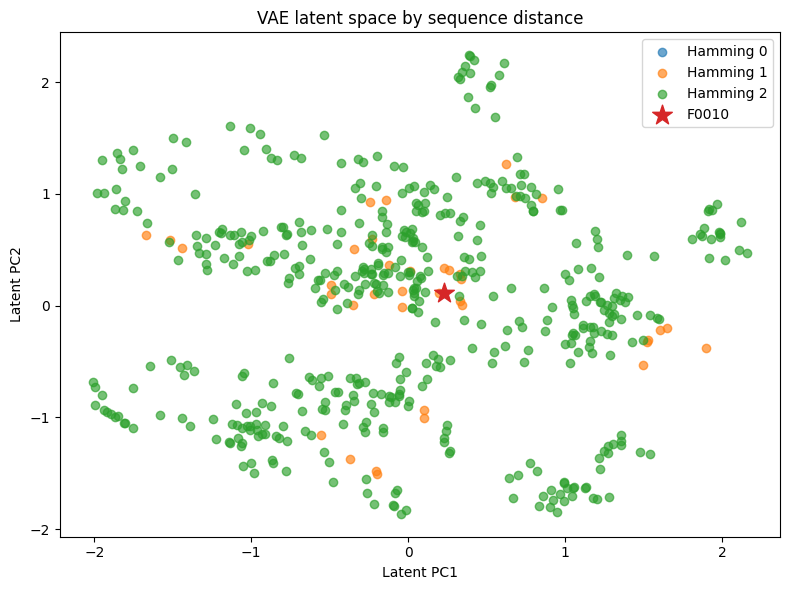

PCA explained variance: [0.29157963 0.27005479]
Total PC1+PC2: 0.5616344215540139


In [8]:
pca = PCA(n_components=2)

latent_2d = pca.fit_transform(Z)

merged["latent_pc1"] = latent_2d[:, 0]
merged["latent_pc2"] = latent_2d[:, 1]

plt.figure(figsize=(8, 6))

for mutation_count in sorted(
    merged["hamming_to_seed"].unique()
):
    subset = merged[
        merged["hamming_to_seed"]
        == mutation_count
    ]

    plt.scatter(
        subset["latent_pc1"],
        subset["latent_pc2"],
        alpha=0.65,
        label=(
            f"Hamming {mutation_count}"
        ),
    )

seed_plot = merged[
    merged[sequence_column]
    == SEED_SEQUENCE
]

plt.scatter(
    seed_plot["latent_pc1"],
    seed_plot["latent_pc2"],
    marker="*",
    s=220,
    label="F0010",
)

plt.xlabel("Latent PC1")
plt.ylabel("Latent PC2")
plt.title("VAE latent space by sequence distance")
plt.legend()
plt.tight_layout()

plt.savefig(
    REPORTS_DIR
    / "latent_pca_by_hamming.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "PCA explained variance:",
    pca.explained_variance_ratio_,
)
print(
    "Total PC1+PC2:",
    pca.explained_variance_ratio_.sum(),
)

## 8. PCA del latent space colorata per target

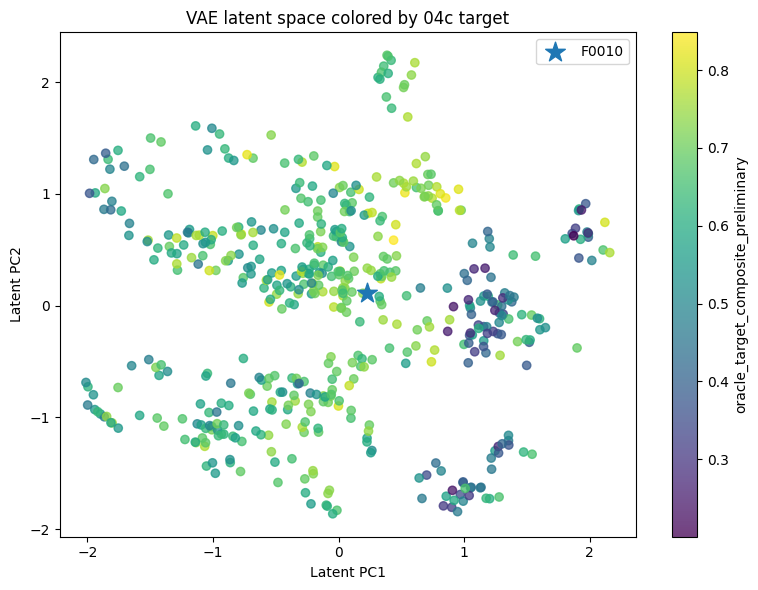

In [9]:
valid_target_mask = merged[
    target_column
].notna()

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    merged.loc[
        valid_target_mask,
        "latent_pc1",
    ],
    merged.loc[
        valid_target_mask,
        "latent_pc2",
    ],
    c=merged.loc[
        valid_target_mask,
        target_column,
    ],
    alpha=0.75,
)

plt.colorbar(
    scatter,
    label=target_column,
)

plt.scatter(
    seed_plot["latent_pc1"],
    seed_plot["latent_pc2"],
    marker="*",
    s=220,
    label="F0010",
)

plt.xlabel("Latent PC1")
plt.ylabel("Latent PC2")
plt.title("VAE latent space colored by 04c target")
plt.legend()
plt.tight_layout()

plt.savefig(
    REPORTS_DIR
    / "latent_pca_by_target.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 9. Relazione tra coordinate latenti e target

In [10]:
latent_target_correlations = []

for column in (
    z_columns
    + ["latent_pc1", "latent_pc2"]
):
    temp = merged[
        [column, target_column]
    ].dropna()

    if len(temp) < 3:
        continue

    pearson_value = pearsonr(
        temp[column],
        temp[target_column],
    ).statistic

    spearman_value = spearmanr(
        temp[column],
        temp[target_column],
    ).statistic

    latent_target_correlations.append({
        "latent_coordinate": column,
        "pearson_vs_target": (
            pearson_value
        ),
        "spearman_vs_target": (
            spearman_value
        ),
    })

latent_target_correlations_df = (
    pd.DataFrame(
        latent_target_correlations
    )
)

display(
    latent_target_correlations_df
)

,latent_coordinate,pearson_vs_target,spearman_vs_target
0,z1,-0.365520,-0.232157
1,z2,-0.030982,0.004051
2,z3,-0.166889,-0.214975
3,z4,-0.070794,-0.060079
4,latent_pc1,-0.242744,-0.143086
5,latent_pc2,0.181046,0.182498


## 10. Quanto target è prevedibile dallo spazio latente?

Questo test non sostituisce l'oracle 04d.

Serve solo come diagnostica: se una regressione semplice riesce a recuperare una parte del target dalle coordinate `z`, significa che lo spazio latente contiene informazione associata alla proprietà che verrà ottimizzata.


In [11]:
latent_target_df = merged[
    z_columns + [target_column]
].dropna()

X_latent = latent_target_df[
    z_columns
].to_numpy()

y_target = latent_target_df[
    target_column
].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(
    X_latent
)

ridge = Ridge(alpha=1.0)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED,
)

r2_scores = cross_val_score(
    ridge,
    X_scaled,
    y_target,
    cv=cv,
    scoring="r2",
)

mae_scores = -cross_val_score(
    ridge,
    X_scaled,
    y_target,
    cv=cv,
    scoring="neg_mean_absolute_error",
)

latent_target_prediction = pd.DataFrame({
    "metric": [
        "R2_mean",
        "R2_std",
        "MAE_mean",
        "MAE_std",
    ],
    "value": [
        r2_scores.mean(),
        r2_scores.std(),
        mae_scores.mean(),
        mae_scores.std(),
    ],
})

display(
    latent_target_prediction
)

,metric,value
0,R2_mean,0.140126
1,R2_std,0.066444
2,MAE_mean,0.095934
3,MAE_std,0.001788


## 11. Smoothness locale del target

Per ogni sequenza troviamo i vicini più prossimi nello spazio latente e confrontiamo il suo target con il target medio dei vicini.

Se il latent space è utile, sequenze vicine dovrebbero avere target relativamente simili.


In [12]:
K_NEIGHBORS = 8

valid = merged[
    merged[target_column].notna()
].copy().reset_index(drop=True)

Z_valid = valid[
    z_columns
].to_numpy(
    dtype=float
)

nn_model = NearestNeighbors(
    n_neighbors=min(
        K_NEIGHBORS + 1,
        len(valid),
    ),
    metric="euclidean",
)

nn_model.fit(Z_valid)

distances, indices = (
    nn_model.kneighbors(Z_valid)
)

neighbor_target_means = []

for row_index in range(
    len(valid)
):
    neighbor_indices = (
        indices[row_index, 1:]
    )

    neighbor_target_means.append(
        valid.iloc[
            neighbor_indices
        ][target_column].mean()
    )

valid[
    "latent_neighbor_target_mean"
] = neighbor_target_means

smoothness_pearson = pearsonr(
    valid[target_column],
    valid[
        "latent_neighbor_target_mean"
    ],
).statistic

smoothness_spearman = spearmanr(
    valid[target_column],
    valid[
        "latent_neighbor_target_mean"
    ],
).statistic

smoothness_mae = float(
    np.mean(
        np.abs(
            valid[target_column]
            - valid[
                "latent_neighbor_target_mean"
            ]
        )
    )
)

print(
    "Neighbor target Pearson:",
    smoothness_pearson,
)
print(
    "Neighbor target Spearman:",
    smoothness_spearman,
)
print(
    "Neighbor target MAE:",
    smoothness_mae,
)

Neighbor target Pearson: 0.6666854010849615
Neighbor target Spearman: 0.6239283817616265
Neighbor target MAE: 0.07412804973819472


## 12. Vicini latenti di F0010

In [13]:
seed_neighbors = (
    merged.sort_values(
        "latent_distance_to_seed"
    )[
        [
            sequence_column,
            "hamming_to_seed",
            "latent_distance_to_seed",
            target_column,
        ]
        + z_columns
    ]
    .head(21)
    .reset_index(drop=True)
)

display(seed_neighbors)

,sequence,hamming_to_seed,latent_distance_to_seed,oracle_target_composite_preliminary,z1,z2,z3,z4
0,IGERCQYRDLK,0,0.000000,0.758631,0.237059,-0.637343,-0.416996,-0.194805
1,IGERSQYRDLQ,2,0.266350,0.725816,0.142282,-0.646569,-0.276743,0.010631
2,IGERSQYRDLH,2,0.284844,0.738116,0.126727,-0.707454,-0.280428,0.018260
3,IGERSQYRDLE,2,0.299262,0.692983,0.215646,-0.782494,-0.269189,0.020100
4,IGERTQYRDLE,2,0.335283,0.675611,0.114095,-0.426826,-0.372932,0.031105
5,IGERTQYRDLN,2,0.390371,0.677575,0.152083,-0.442888,-0.200486,0.051120
6,IGERCQYHDLK,1,0.394255,0.670767,0.208476,-0.583907,-0.578929,-0.549124
7,IGERTQYRDLH,2,0.428716,0.659864,0.011313,-0.333270,-0.392833,0.004673
8,IGERSQYRDLR,2,0.430842,0.765511,-0.000155,-0.774628,-0.181514,0.039835
9,IGERTQYRDLQ,2,0.465532,0.644648,0.032755,-0.276427,-0.385251,0.014268


## 13. Posizione dei controfattuali CLEAR già noti

Questi candidati derivano dalla Pipeline 2 consolidata e vengono usati qui **solo come riferimenti diagnostici** nel latent space.


In [14]:
KNOWN_CANDIDATES = {
    "F0010": "IGERCQYRDLK",
    "CF_01": "IGERCEYKDLK",
    "CF_02": "IGERSQYRELK",
    "CF_03": "IGERCQYRELK",
    "CF_05": "IGERCEYRELK",
    "CF_06": "IGERCQYRELR",
    "CF_10": "IGERCQYRELQ",
}

known_rows = []

for candidate_id, sequence in (
    KNOWN_CANDIDATES.items()
):
    match = merged[
        merged[sequence_column]
        == sequence
    ]

    if match.empty:
        known_rows.append({
            "candidate_id": candidate_id,
            "sequence": sequence,
            "present_in_04c_latent": False,
        })
        continue

    row = match.iloc[0]

    result = {
        "candidate_id": candidate_id,
        "sequence": sequence,
        "present_in_04c_latent": True,
        "hamming_to_seed": (
            row["hamming_to_seed"]
        ),
        "latent_distance_to_seed": (
            row[
                "latent_distance_to_seed"
            ]
        ),
        "target": (
            row[target_column]
        ),
        "latent_pc1": row["latent_pc1"],
        "latent_pc2": row["latent_pc2"],
    }

    for z_column in z_columns:
        result[z_column] = row[z_column]

    known_rows.append(result)

known_candidates_df = pd.DataFrame(
    known_rows
)

display(known_candidates_df)

,candidate_id,sequence,present_in_04c_latent,hamming_to_seed,latent_distance_to_seed,target,latent_pc1,latent_pc2,z1,z2,z3,z4
0,F0010,IGERCQYRDLK,True,0.0,0.000000,0.758631,0.228562,0.116001,0.237059,-0.637343,-0.416996,-0.194805
1,CF_01,IGERCEYKDLK,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CF_02,IGERSQYRELK,True,2.0,1.243637,0.848590,0.438247,0.586388,0.146038,-1.623904,-1.167792,-0.231555
3,CF_03,IGERCQYRELK,True,1.0,1.382639,0.836643,0.853354,0.964292,0.240821,-0.316298,-1.729072,-0.489869
4,CF_05,IGERCEYRELK,True,2.0,1.275845,0.797925,0.163040,1.040600,-0.327206,-0.009211,-1.373340,-0.210325
5,CF_06,IGERCQYRELR,True,2.0,1.558409,0.829395,0.528204,1.010916,0.105271,0.626769,-1.313931,-0.101014
6,CF_10,IGERCQYRELQ,True,2.0,1.716230,0.776086,0.745311,0.962353,0.288020,0.779022,-1.384574,-0.218222


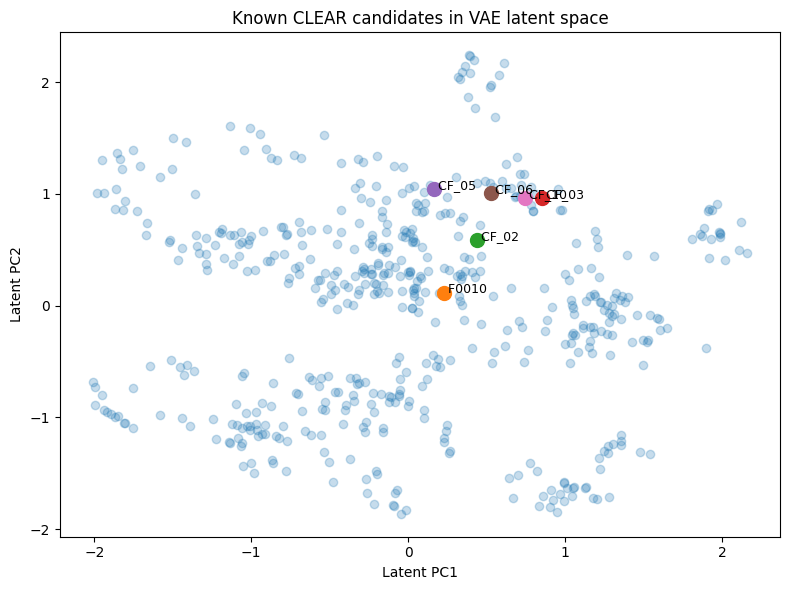

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    merged["latent_pc1"],
    merged["latent_pc2"],
    alpha=0.25,
)

for _, row in (
    known_candidates_df[
        known_candidates_df[
            "present_in_04c_latent"
        ] == True
    ].iterrows()
):
    plt.scatter(
        row["latent_pc1"],
        row["latent_pc2"],
        s=100,
    )

    plt.text(
        row["latent_pc1"],
        row["latent_pc2"],
        " " + row["candidate_id"],
        fontsize=9,
    )

plt.xlabel("Latent PC1")
plt.ylabel("Latent PC2")
plt.title("Known CLEAR candidates in VAE latent space")
plt.tight_layout()

plt.savefig(
    REPORTS_DIR
    / "known_clear_candidates_latent_space.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 14. Gradient proxy del target nello spazio latente

Non eseguiamo ancora counterfactual optimization.

Adattiamo però una regressione Ridge sul latent space completo e stimiamo la direzione lineare locale associata a target crescente. Questo serve solo per capire se esiste una **direzione latente interpretabile** da esplorare nel 06c.


In [16]:
ridge_full = Ridge(alpha=1.0)

ridge_full.fit(
    X_scaled,
    y_target,
)

latent_direction_scaled = (
    ridge_full.coef_.copy()
)

latent_direction_norm = float(
    np.linalg.norm(
        latent_direction_scaled
    )
)

if latent_direction_norm > 0:
    normalized_direction = (
        latent_direction_scaled
        / latent_direction_norm
    )
else:
    normalized_direction = (
        latent_direction_scaled
    )

direction_df = pd.DataFrame({
    "latent_coordinate": z_columns,
    "ridge_coefficient_standardized": (
        latent_direction_scaled
    ),
    "normalized_direction": (
        normalized_direction
    ),
})

display(direction_df)

print(
    "Latent target-direction norm:",
    latent_direction_norm,
)

,latent_coordinate,ridge_coefficient_standardized,normalized_direction
0,z1,-0.046897,-0.881906
1,z2,-0.004151,-0.078058
2,z3,-0.022741,-0.427655
3,z4,-0.009698,-0.182372


Latent target-direction norm: 0.053176415356132024


## 15. Diagnostica di readiness per il 06c

Questi criteri sono volutamente **diagnostici**, non una certificazione matematica.

Il 06c è ragionevole se:

- il seed è rappresentato;
- il latent space ha varianza;
- la distanza latente conserva almeno moderatamente la distanza di sequenza;
- il target presenta smoothness locale;
- una parte del target è recuperabile dalle coordinate latenti.

Una mancata soglia non rende il VAE "falso": indica che prima del 06c può essere utile un `06a-v2`.


In [17]:
mean_latent_std = float(
    merged[z_columns]
    .std()
    .mean()
)

latent_hamming_spearman = float(
    spearman_hamming_latent.statistic
)

target_smoothness_spearman = float(
    smoothness_spearman
)

latent_target_r2 = float(
    r2_scores.mean()
)

readiness_checks = pd.DataFrame([
    {
        "check": "F0010 present in latent space",
        "passed": not seed_rows.empty,
        "value": 1.0,
    },
    {
        "check": "mean latent std > 0.01",
        "passed": (
            mean_latent_std > 0.01
        ),
        "value": mean_latent_std,
    },
    {
        "check": (
            "Spearman(Hamming, latent distance) > 0.20"
        ),
        "passed": (
            latent_hamming_spearman
            > 0.20
        ),
        "value": latent_hamming_spearman,
    },
    {
        "check": (
            "local target smoothness Spearman > 0.30"
        ),
        "passed": (
            target_smoothness_spearman
            > 0.30
        ),
        "value": target_smoothness_spearman,
    },
    {
        "check": (
            "latent-only Ridge CV R2 > 0.10"
        ),
        "passed": (
            latent_target_r2 > 0.10
        ),
        "value": latent_target_r2,
    },
])

display(readiness_checks)

N_PASSED = int(
    readiness_checks[
        "passed"
    ].sum()
)

N_CHECKS = len(
    readiness_checks
)

if N_PASSED == N_CHECKS:
    READINESS_STATUS = (
        "READY_FOR_06C"
    )
elif N_PASSED >= 3:
    READINESS_STATUS = (
        "CONDITIONALLY_READY_FOR_06C"
    )
else:
    READINESS_STATUS = (
        "RETRAIN_06A_BEFORE_06C"
    )

print(
    "06c readiness:",
    READINESS_STATUS,
    f"({N_PASSED}/{N_CHECKS} checks passed)",
)

,check,passed,value
0,F0010 present in latent space,True,1.000000
1,mean latent std > 0.01,True,0.877891
2,"Spearman(Hamming, latent distance) > 0.20",True,0.595039
3,local target smoothness Spearman > 0.30,True,0.623928
4,latent-only Ridge CV R2 > 0.10,True,0.140126


06c readiness: READY_FOR_06C (5/5 checks passed)


## 16. Esportazione

In [18]:
MERGED_CSV = (
    RESULT_DIR
    / "vae_latent_with_04c_target.csv"
)

PAIR_DISTANCE_CSV = (
    RESULT_DIR
    / "latent_vs_hamming_pair_distances.csv"
)

CORRELATIONS_CSV = (
    RESULT_DIR
    / "latent_target_correlations.csv"
)

LATENT_TARGET_PREDICTION_CSV = (
    RESULT_DIR
    / "latent_target_prediction_cv.csv"
)

SMOOTHNESS_CSV = (
    RESULT_DIR
    / "latent_target_local_smoothness.csv"
)

SEED_NEIGHBORS_CSV = (
    RESULT_DIR
    / "f0010_latent_nearest_neighbors.csv"
)

KNOWN_CANDIDATES_CSV = (
    RESULT_DIR
    / "known_clear_candidates_latent_positions.csv"
)

DIRECTION_CSV = (
    RESULT_DIR
    / "latent_target_direction_proxy.csv"
)

READINESS_CSV = (
    RESULT_DIR
    / "06c_readiness_checks.csv"
)

merged.to_csv(
    MERGED_CSV,
    index=False,
)

pair_distance_df.to_csv(
    PAIR_DISTANCE_CSV,
    index=False,
)

latent_target_correlations_df.to_csv(
    CORRELATIONS_CSV,
    index=False,
)

latent_target_prediction.to_csv(
    LATENT_TARGET_PREDICTION_CSV,
    index=False,
)

valid[
    [
        sequence_column,
        target_column,
        "latent_neighbor_target_mean",
    ]
].to_csv(
    SMOOTHNESS_CSV,
    index=False,
)

seed_neighbors.to_csv(
    SEED_NEIGHBORS_CSV,
    index=False,
)

known_candidates_df.to_csv(
    KNOWN_CANDIDATES_CSV,
    index=False,
)

direction_df.to_csv(
    DIRECTION_CSV,
    index=False,
)

readiness_checks.to_csv(
    READINESS_CSV,
    index=False,
)

for path in [
    MERGED_CSV,
    PAIR_DISTANCE_CSV,
    CORRELATIONS_CSV,
    LATENT_TARGET_PREDICTION_CSV,
    SMOOTHNESS_CSV,
    SEED_NEIGHBORS_CSV,
    KNOWN_CANDIDATES_CSV,
    DIRECTION_CSV,
    READINESS_CSV,
]:
    print("Salvato:", path.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/vae_latent_with_04c_target.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/latent_vs_hamming_pair_distances.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/latent_target_correlations.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/latent_target_prediction_cv.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/latent_target_local_smoothness.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/f0010_latent_nearest_neighbors.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/known_clear_candidates_latent_positions.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/latent_target_direction_proxy.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_vae_06b/06c_readiness_checks.csv


## 17. Report automatico

In [19]:
report = f'''# 06b — CLEAR VAE Latent-Space Analysis

## Input
- Latent embeddings: `{LATENT_PATH}`
- Dataset 04c: `{DATASET_PATH}`
- Sequenze analizzate: {len(merged)}
- Latent dimensions: {len(z_columns)}
- Target: `{target_column}`

## Sequence-locality diagnostics
- Mean latent std: {mean_latent_std:.6f}
- Pearson Hamming vs latent distance: {pearson_hamming_latent.statistic:.6f}
- Spearman Hamming vs latent distance: {spearman_hamming_latent.statistic:.6f}

## Target structure in latent space
- Local-neighbor target Pearson: {smoothness_pearson:.6f}
- Local-neighbor target Spearman: {smoothness_spearman:.6f}
- Local-neighbor target MAE: {smoothness_mae:.6f}
- Latent-only Ridge CV R2: {r2_scores.mean():.6f} ± {r2_scores.std():.6f}
- Latent-only Ridge CV MAE: {mae_scores.mean():.6f} ± {mae_scores.std():.6f}

## 06c readiness
- Checks passed: {N_PASSED}/{N_CHECKS}
- Status: `{READINESS_STATUS}`

## Interpretazione
Il 06b è una diagnostica dello spazio latente del vero VAE.
Non genera ancora controfattuali.

`READY_FOR_06C` indica che località di sequenza e struttura del target sono sufficientemente rappresentate per tentare una ricerca counterfactual nello spazio latente.

`CONDITIONALLY_READY_FOR_06C` indica che il 06c può essere tentato con forti vincoli e controlli, mantenendo la possibilità di addestrare un 06a-v2.

`RETRAIN_06A_BEFORE_06C` indica che la geometria latente non è abbastanza informativa e conviene migliorare il VAE prima dell'ottimizzazione.
'''

REPORT_PATH = (
    REPORTS_DIR
    / "06b_vae_latent_space_report.md"
)

REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print(
    "Report:",
    REPORT_PATH.resolve(),
)

# 06b — CLEAR VAE Latent-Space Analysis

## Input
- Latent embeddings: `outputs/clear_peptide_vae_06a/vae_latent_embeddings.csv`
- Dataset 04c: `outputs/clear_local_peptide_dataset_04c/clear_local_peptide_variant_dataset_labeled.csv`
- Sequenze analizzate: 539
- Latent dimensions: 4
- Target: `oracle_target_composite_preliminary`

## Sequence-locality diagnostics
- Mean latent std: 0.877891
- Pearson Hamming vs latent distance: 0.604432
- Spearman Hamming vs latent distance: 0.595039

## Target structure in latent space
- Local-neighbor target Pearson: 0.666685
- Local-neighbor target Spearman: 0.623928
- Local-neighbor target MAE: 0.074128
- Latent-only Ridge CV R2: 0.140126 ± 0.066444
- Latent-only Ridge CV MAE: 0.095934 ± 0.001788

## 06c readiness
- Checks passed: 5/5
- Status: `READY_FOR_06C`

## Interpretazione
Il 06b è una diagnostica dello spazio latente del vero VAE.
Non genera ancora controfattuali.

`READY_FOR_06C` indica che località di sequenza e struttura del target sono 

## 18. Passaggio successivo

Interpretare prima:

```text
06c readiness: ...
```

### Se `READY_FOR_06C`
Procedere con:

```text
06c_CLEAR_VAE_Latent_Counterfactual_Optimization.ipynb
```

### Se `CONDITIONALLY_READY_FOR_06C`
È possibile costruire il 06c, ma con:

- raggio massimo attorno a `z_F0010`;
- decoding vincolato;
- massimo 1–2 mutazioni;
- posizioni protette;
- sostituzioni ammesse dal 04c;
- confronto obbligatorio con l'oracle 04d;
- nessuna interpretazione del VAE come generatore validato globalmente.

### Se `RETRAIN_06A_BEFORE_06C`
Preparare prima un `06a-v2` modificando, ad esempio:

- `BETA_KL`;
- capacità encoder/decoder;
- latent dimension;
- KL annealing;
- loss pesata sulle posizioni mutate.

La decisione viene presa dai risultati eseguiti, non a priori.
